- (DONE) do initial EDA
- (DONE) how many data jobs are there in the data set?
- (DONE) how many work years are represented?
- (DONE) which countries exists in this dataset?
- (DONE) what type of company sizes are there
- (DONE) ratio of remote work vs office
- average salaries per job role
- median salaries per job role
- seniority level and average salaries?
- remote work and average salaries?
- company location and average salaries?
- clean job titles
- do different visualizations
- export visualizations
- export cleaned data

# do initial EDA

In [1]:
import pandas as pd

df = pd.read_csv("salaries.csv")

df.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2024,SE,FT,AI Engineer,202730,USD,202730,US,0,US,M
1,2024,SE,FT,AI Engineer,92118,USD,92118,US,0,US,M
2,2024,SE,FT,Data Engineer,130500,USD,130500,US,0,US,M
3,2024,SE,FT,Data Engineer,96000,USD,96000,US,0,US,M
4,2024,SE,FT,Machine Learning Engineer,190000,USD,190000,US,0,US,M


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16534 entries, 0 to 16533
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   work_year           16534 non-null  int64 
 1   experience_level    16534 non-null  object
 2   employment_type     16534 non-null  object
 3   job_title           16534 non-null  object
 4   salary              16534 non-null  int64 
 5   salary_currency     16534 non-null  object
 6   salary_in_usd       16534 non-null  int64 
 7   employee_residence  16534 non-null  object
 8   remote_ratio        16534 non-null  int64 
 9   company_location    16534 non-null  object
 10  company_size        16534 non-null  object
dtypes: int64(4), object(7)
memory usage: 1.4+ MB


In [37]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
work_year,16534.0,2023.226866,0.713558,2020.0,2023.0,2023.0,2024.0,2024.0
salary,16534.0,163726.962683,340205.744183,14000.0,101763.0,142200.0,187200.0,30400000.0
salary_in_usd,16534.0,149686.777973,68505.293156,15000.0,101125.0,141300.0,185900.0,800000.0
remote_ratio,16534.0,32.003750,46.245158,0.0,0.0,0.0,100.0,100.0


## how many data jobs are there in the data set?
- 16534 rows = 16534 jobs
- 11 columns

In [39]:
df["job_title"].value_counts().head(10)

job_title
Data Engineer                3464
Data Scientist               3314
Data Analyst                 2440
Machine Learning Engineer    1705
Research Scientist            531
Applied Scientist             435
Data Architect                435
Analytics Engineer            431
Research Engineer             306
Data Science                  271
Name: count, dtype: int64

In [12]:
df["job_title"].nunique()

155

## How many work years are represented?

In [5]:
df["work_year"].nunique()

print(f"There are {df['work_year'].nunique()} unique work years in the dataset.")

There are 5 unique work years in the dataset.


## Which countries exists in this dataset?

In [15]:
print(f"There are {df['employee_residence'].nunique()} unique employee residences in the dataset.")

df["employee_residence"].value_counts().head(10)

There are 88 unique employee residences in the dataset.


employee_residence
US    14467
GB      686
CA      453
ES      137
DE       98
IN       78
FR       69
AU       54
NL       32
PT       30
Name: count, dtype: int64

In [16]:
print(f"There are {df['company_location'].nunique()} unique company locations in the dataset.")

df["company_location"].value_counts().head(10)

There are 77 unique company locations in the dataset.


company_location
US    14518
GB      694
CA      455
ES      133
DE      105
FR       65
IN       63
AU       57
NL       32
PT       28
Name: count, dtype: int64

## What type of company sizes are there

In [27]:
df["company_size"].value_counts(normalize=True).sort_index(ascending=False)

company_size
S    0.011371
M    0.925729
L    0.062901
Name: proportion, dtype: float64

In [28]:
df["company_size"].value_counts().sort_index(ascending=False)

company_size
S      188
M    15306
L     1040
Name: count, dtype: int64

## Ratio of remote work vs office

In [29]:
df["remote_ratio"].value_counts().sort_index(ascending=False)

remote_ratio
100     5167
50       249
0      11118
Name: count, dtype: int64

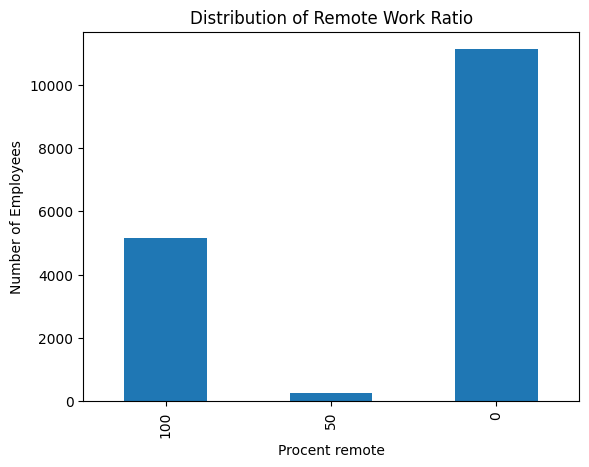

In [45]:
ax = df["remote_ratio"].value_counts().sort_index(ascending=False).plot(
    kind="bar", 
    ylabel="Number of Employees", 
    xlabel="Procent remote", 
    title="Distribution of Remote Work Ratio")

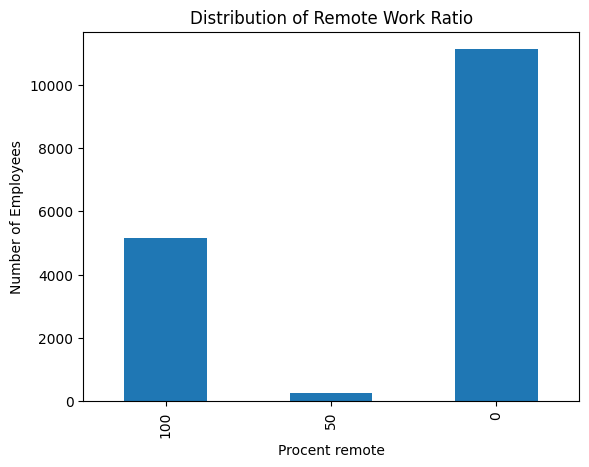

In [51]:
fig = ax.get_figure()
fig.savefig("remote_ratio_distribution.png", dpi=300)
fig

In [44]:

df["remote_ratio"].value_counts(normalize=True).sort_index(ascending=False)

remote_ratio
100    0.312508
50     0.015060
0      0.672433
Name: proportion, dtype: float64

In [ ]:
df.["company_location"].

## Parts of DataFrame
- Categorical
    - Sorting columns to group data

- Values
    - Calcylatable data (e.g INT FLOAT)

- Non-categorial strings


In [52]:
import duckdb

duckdb.sql("""
    FROM df
    WHERE job_title ILIKE 'data scie%'
"""
).df()["job_title"].value_counts()

job_title
Data Scientist               3314
Data Science                  271
Data Science Manager          122
Data Science Consultant        83
Data Science Engineer          29
Data Science Lead              26
Data Science Practitioner      16
Data Science Director           8
Data Science Analyst            4
Data Scientist Lead             2
Data Science Tech Lead          1
Name: count, dtype: int64

In [53]:
duckdb.sql("""
    SELECT
        * EXCLUDE job_title,
        CASE
            WHEN job_title ILIKE 'data scie%' THEN 'data scientist'
            ELSE job_title
        END AS job_title
    FROM df
    WHERE job_title ILIKE 'data scie%'
""").df()["job_title"].value_counts()

job_title
data scientist    3876
Name: count, dtype: int64